In [22]:
import numpy as np
import bayesflow as bf
import scipy.stats as stats
import bayesflow.diagnostics as diag
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def theta_step(alpha=2, beta=1.0):
    
    # 1. mu ~ Normal(loc=mu, scale=sigma)
    sigma_val = 1/np.random.gamma(shape=alpha, scale=1/beta)
    sigma_sample = np.float32(sigma_val)
    
    # 2. 
    theta = np.array([sigma_sample], dtype=np.float32)
    return {"theta": theta}

def forward_step(theta, **kwargs):
    
    sigma2 = theta[0]   
    
    obs = np.random.normal(loc=0, scale=np.sqrt(sigma2), size=(100, 1)).astype(np.float32)
    
    return {"x": obs}


In [ ]:
simulator = bf.make_simulator(
    [theta_step, forward_step],
    expand_outputs=False
)

def flatten_inference_conditions(data, **kwargs):
    if "inference_conditions" in data:
        conditions = data["inference_conditions"]
        data["inference_conditions"] = conditions.reshape(conditions.shape[0], -1)
    return data

adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype("float64", "float32")  # Ensure data is float32
    .rename("theta", "inference_variables")
    .rename("x", "inference_conditions")
    .append(flatten_inference_conditions)  # Add flattening step
)


In [5]:
num_training_batches   = 500
num_batch_size            = 32
num_epochs                = 15

In [9]:
affine_flow = bf.networks.CouplingFlow(subnet="mlp")

affine_flow_workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=affine_flow,
)



In [10]:
history = affine_flow_workflow.fit_online(
    epochs=num_epochs,
    number_batches=num_training_batches,
    batch_size=num_batch_size,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 74.8394 - loss/inference_loss: 74.8394
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.7153 - loss/inference_loss: 1.7153
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -0.1909 - loss/inference_loss: -0.1909
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.1564 - loss/inference_loss: -0.1564
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: -0.5569 - loss/inference_loss: -0.5569
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.5232 - loss/inference_loss: -0.5232
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.6129 - loss/inference_loss: -0.6129
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.5902 - loss/inference_loss: -0.5902
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: -0.1793 - loss/inference_loss: -0.1793
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.2606 - loss/inference_loss: 1.2606
Epo

In [66]:
test_size = 1 
test_batch = simulator.sample((test_size,))

theta_true = test_batch["theta"]
x_test = test_batch["x"] 

num_samples = 300

posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test}, 
    num_samples=num_samples
)["theta"]

In [67]:
import numpy as np

def bayes_estimator(Z, alpha_0=2.0, beta_0=1.0, n_samples=1000):
    """
    Implements a Bayesian estimator that calculates the posterior distribution 
    based on the prior and observed data, and samples from it using numpy.

    Parameters:
    - Z: Input data, expected shape (batch_size, n_obs, 1).
    - alpha_0: Initial shape parameter of the Inverse-Gamma distribution.
    - beta_0: Initial scale parameter of the Inverse-Gamma distribution.
    - n_samples: Number of posterior samples to draw.

    Returns:
    - posterior_samples: Samples drawn from the posterior distribution, shape (n_samples, batch_size).
    """
    # Ensure Z is a numpy array
    Z = np.array(Z, dtype=np.float32)

    # Compute the mean over the observation dimension (axis=1)
    y_bar = np.mean(Z, axis=1, keepdims=True)  # Shape: (batch_size, 1, 1)
    n = Z.shape[1]  # Number of observations (n_obs), scalar

    # Compute the sum of squared differences from y_bar
    variance = np.sum(np.square(Z - y_bar), axis=1, keepdims=True)  # Shape: (batch_size, 1)

    # Update the posterior parameters for the Inverse-Gamma distribution
    alpha = alpha_0 + n / 2  # Shape: scalar
    beta = beta_0 + variance / 2  # Shape: (batch_size, 1)

    # Sample from the posterior Inverse-Gamma distribution using numpy
    posterior_samples = np.random.gamma(shape=alpha, scale=1 / beta, size=(n_samples, beta.shape[0], 1))  # Shape: (n_samples, batch_size, 1)

    return 1 / posterior_samples.squeeze()  # Inverse-Gamma is the reciprocal of Gamma


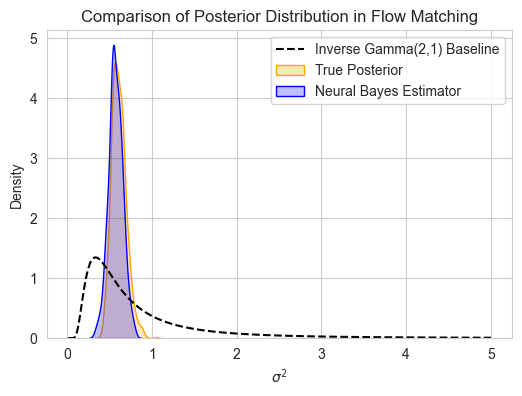

In [68]:

mu_samples = posterior_samples_affine[0, :, -1]
mu_true = theta_true[0, -1]  

plt.figure(figsize=(6, 4))


x = np.linspace(0.01, 5, 1000) 
y = stats.invgamma.pdf(x, a=2, scale=1) 

plt.plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

reference_posterior = bayes_estimator(x_test)

sns.kdeplot(reference_posterior, label="True Posterior", fill=True, color="orange")
sns.kdeplot(mu_samples,  fill=True, color="blue", label="Neural Bayes Estimator")
plt.title("Comparison of Posterior Distribution in Flow Matching")
plt.xlabel("$\sigma^2$")
plt.ylabel("Density")
plt.legend()
plt.show()



In [72]:
test_size = 100
test_batch_100 = simulator.sample((test_size,))

theta_true_100 = test_batch_100["theta"] 
x_test_100 = test_batch_100["x"]

In [73]:
posterior_samples_affine= affine_flow_workflow.approximator.sample(
    conditions={"inference_conditions": x_test_100},
    num_samples=300
)["theta"]

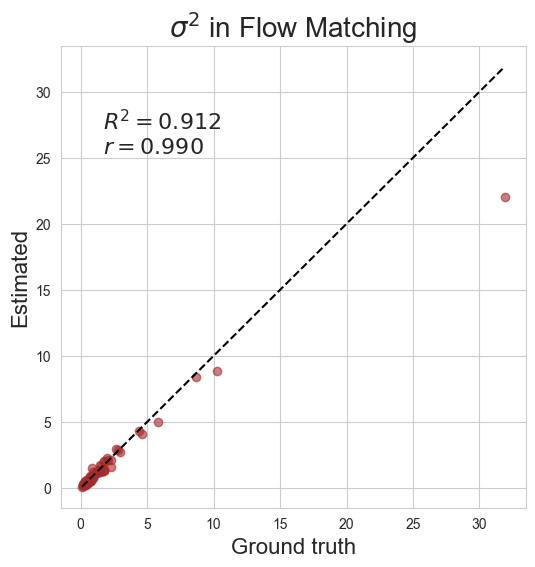

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

posterior_means = posterior_samples_affine.mean(axis=1)

# Select the first dimension
i = 0

plt.figure(figsize=(6, 6))
plt.scatter(theta_true_100[:, i], posterior_means[:, i], alpha=0.6, color="brown")

# 45-degree line
min_val = min(theta_true_100[:, i].min(), posterior_means[:, i].min())
max_val = max(theta_true_100[:, i].max(), posterior_means[:, i].max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")

# Calculate R² and r
r = np.corrcoef(theta_true_100[:, i], posterior_means[:, i])[0, 1]
r2 = r2_score(theta_true_100[:, i], posterior_means[:, i])

# Annotate the plot
plt.text(min_val + 0.05 * (max_val - min_val), 
         max_val - 0.1 * (max_val - min_val), 
         f'$R^2 = {r2:.3f}$\n$r = {r:.3f}$', 
         fontsize=16, 
         ha='left', 
         va='top')

plt.title(r"$\sigma^2$ in Flow Matching", fontsize=20)
plt.xlabel("Ground truth", fontsize=16)
plt.ylabel("Estimated", fontsize=16)

plt.show()


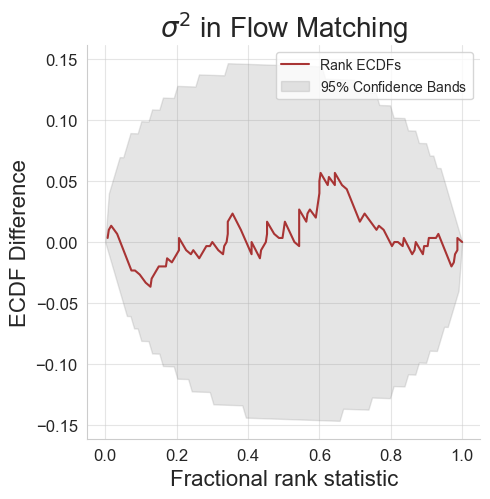

In [ ]:
import matplotlib.pyplot as plt

f = diag.calibration_ecdf(
    targets=posterior_samples_affine,
    references=theta_true_100,
    stacked=True,
    difference=True,
    legend_fontsize=12,
    figsize=(5, 5)
)

# Modify legend colors
for i, line in enumerate(f.axes[0].get_lines()):
    if i == 0:  # First legend line in brown
        line.set_color("brown")
    else:
        line.set_color("gray")  # Keep confidence interval in gray

# Modify legend color
legend = f.axes[0].legend()
legend.get_lines()[0].set_color("brown")  # Set first legend line to brown

# Change title to \sigma^2
f.axes[0].set_title(r"$\sigma^2$ in Flow Matching", fontsize=20) 

plt.show()
